In [ ]:
!pip install PyWavelets

# generate and plot signals

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# Constants
f_phase = 5     # frequency for phase component in Hz
f_amp = 60      # frequency for amplitude component in Hz
kp = 1          # constant for phase signal
ka = 1          # constant for amplitude signal
sigma_n = 0  # noise standard deviation
chi = 1      # parameter between 0 and 1



def signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi):

    # Time vector
    fs = 500  # Sampling rate
    t = np.linspace(0, 1, fs, endpoint=False)  # Time from 0 to 1 sec

    # Generate white Gaussian noise
    n1 = np.random.normal(0, 1, size=t.shape)
    n2 = np.random.normal(0, 1, size=t.shape)

    # Signals
    x_p = kp * np.cos(2 * np.pi * f_phase * t) + sigma_n * n1

    modulation = ((1 - chi) * np.cos(2 * np.pi * f_phase * t) + chi + 1) / 2
    x_a = ka * modulation * np.cos(2 * np.pi * f_amp * t) + sigma_n * n2
    return x_p, x_a, n1, n2,t

x_p, x_a, n1, n2,t = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi)

signal = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi) # Plotting the signals
plt.figure(figsize=(12, 6))

plt.plot(t, x_p, label='x_p(t)')
plt.plot(t, x_a, label='x_a(t)', color='orange')

plt.title('Phase Modulated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

plt.plot(t, n1, label='n1(t)')
plt.plot(t, n2, label='n2(t)', color='orange')

plt.title('Phase Modulated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()




import numpy as np
import matplotlib.pyplot as plt



# Constants
f_phase = 5     # frequency for phase component in Hz
f_amp = 60      # frequency for amplitude component in Hz
kp = 1          # constant for phase signal
ka = 1          # constant for amplitude signal
sigma_n = 0  # noise standard deviation
chi = 1      # parameter between 0 and 1



def signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi):

    # Time vector
    fs = 500  # Sampling rate
    t = np.linspace(0, 1, fs, endpoint=False)  # Time from 0 to 1 sec

    # Generate white Gaussian noise
    n1 = np.random.normal(0, 1, size=t.shape)
    n2 = np.random.normal(0, 1, size=t.shape)

    # Signals
    x_p = kp * np.cos(2 * np.pi * f_phase * t) + sigma_n * n1

    modulation = ((1 - chi) * np.cos(2 * np.pi * f_phase * t) + chi + 1) / 2
    x_a = ka * modulation * np.cos(2 * np.pi * f_amp * t) + sigma_n * n2
    return x_p, x_a, n1, n2,t

x_p, x_a, n1, n2,t = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi)

signal = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi) # Plotting the signals
plt.figure(figsize=(12, 6))

plt.plot(t, x_p, label='x_p(t)')
plt.plot(t, x_a, label='x_a(t)', color='orange')

plt.title('Phase Modulated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

plt.plot(t, n1, label='n1(t)')
plt.plot(t, n2, label='n2(t)', color='orange')

plt.title('Phase Modulated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()




import numpy as np
import matplotlib.pyplot as plt



# Constants
f_phase = 5     # frequency for phase component in Hz
f_amp = 60      # frequency for amplitude component in Hz
kp = 1          # constant for phase signal
ka = 1          # constant for amplitude signal
sigma_n = 0  # noise standard deviation
chi = 1      # parameter between 0 and 1



def signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi):

    # Time vector
    fs = 500  # Sampling rate
    t = np.linspace(0, 1, fs, endpoint=False)  # Time from 0 to 1 sec

    # Generate white Gaussian noise
    n1 = np.random.normal(0, 1, size=t.shape)
    n2 = np.random.normal(0, 1, size=t.shape)

    # Signals
    x_p = kp * np.cos(2 * np.pi * f_phase * t) + sigma_n * n1

    modulation = ((1 - chi) * np.cos(2 * np.pi * f_phase * t) + chi + 1) / 2
    x_a = ka * modulation * np.cos(2 * np.pi * f_amp * t) + sigma_n * n2
    return x_p, x_a, n1, n2,t

x_p, x_a, n1, n2,t = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi)

signal = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi) # Plotting the signals
plt.figure(figsize=(12, 6))

plt.plot(t, x_p, label='x_p(t)')
plt.plot(t, x_a, label='x_a(t)', color='orange')

plt.title('Phase Modulated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

plt.plot(t, n1, label='n1(t)')
plt.plot(t, n2, label='n2(t)', color='orange')

plt.title('Phase Modulated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()





#decompose phase and amplitude

In [ ]:
import pywt

def time_frequency_analysis_pywt(x_p, x_a, fs=500):
    """
    Perform wavelet transform using pywt.cwt on x_p and x_a.
    Returns:
        - Phase matrix φ(t, f) for f in 2-12 Hz from x_p
        - Amplitude matrix A(t, f) for f in 20-80 Hz from x_a
    """
    # Define frequency ranges
    f_p = np.arange(2, 13)    # 2 to 12 Hz
    f_a = np.arange(20, 81)   # 20 to 80 Hz

    # Choose wavelet
    wavelet = 'cmor1.5-1.0'   # Complex Morlet wavelet (adjust bandwidth/center freq if needed)

    # Compute CWT for x_p
    coef_p, _ = pywt.cwt(x_p, f_p, wavelet, sampling_period=1/fs)
    phi_tf = np.angle(coef_p)  # Phase φ(t, f)

    # Apply the mask to select the relevant rows (frequencies) in phi_tf
    freq_mask = np.logical_and(f_p >= 2, f_p <= 12)
    phi_tf = phi_tf[freq_mask, :]



    # Compute CWT for x_a
    coef_a, _ = pywt.cwt(x_a, f_a, wavelet, sampling_period=1/fs)
    A_tf = np.abs(coef_a)  # Amplitude A(t, f)

    # Apply the mask to select the relevant rows (amplitudes) in A_tf
    freq_mask2 = np.logical_and(f_a >= 20, f_a <= 80)
    A_tf = A_tf[freq_mask2, :]


    return phi_tf, A_tf, f_p, f_a

phi_tf, A_tf, f_p, f_a = time_frequency_analysis_pywt(x_p, x_a, fs=500)

phi_n , A_n ,f_p ,f_a = time_frequency_analysis_pywt(n1, n2, fs=500)


"""
    Creates a scatter plot of phase vs. amplitude.

    Args:
        phi_tf: Phase matrix.
        A_tf: Amplitude matrix.
    """

def plot_phase_vs_amplitude(phi_tf, A_tf):

    # Flatten the matrices to 1D arrays for plotting
    phi_tf_flat = phi_tf.flatten()
    A_tf_flat = A_tf.flatten()

    min_len = min(len(phi_tf_flat), len(A_tf_flat))  # Get the minimum length
    phi_tf_flat = phi_tf_flat[:min_len].reshape(-1, 1)  # Truncate to equal lengths
    A_tf_flat = A_tf_flat[:min_len].reshape(-1, 1)  # Truncate to equal lengths

    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(phi_tf_flat, A_tf_flat, s=5, alpha=0.5)  # s: marker size, alpha: transparency
    plt.xlabel('Phase ')
    plt.ylabel('Amplitude ')
    plt.title('Phase vs. Amplitude')
    plt.grid(True)
    plt.show()
    return phi_tf_flat, A_tf_flat

phi_tf_flat, A_tf_flat=plot_phase_vs_amplitude(phi_tf=phi_tf, A_tf=A_tf )

plot_phase_vs_amplitude(phi_tf=phi_n, A_tf=A_n)
"""
    Creates a scatter plot of phase vs. amplitude.

    Args:
        phi_tf: Phase matrix.
        A_tf: Amplitude matrix.
    """

def plot_phase_vs_amplitude(phi_tf, A_tf):

    # Flatten the matrices to 1D arrays for plotting
    phi_tf_flat = phi_tf.flatten()
    A_tf_flat = A_tf.flatten()

    min_len = min(len(phi_tf_flat), len(A_tf_flat))  # Get the minimum length
    phi_tf_flat = phi_tf_flat[:min_len].reshape(-1, 1)  # Truncate to equal lengths
    A_tf_flat = A_tf_flat[:min_len].reshape(-1, 1)  # Truncate to equal lengths

    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(phi_tf_flat, A_tf_flat, s=5, alpha=0.5)  # s: marker size, alpha: transparency
    plt.xlabel('Phase ')
    plt.ylabel('Amplitude ')
    plt.title('Phase vs. Amplitude')
    plt.grid(True)
    plt.show()
    return phi_tf_flat, A_tf_flat

phi_tf_flat, A_tf_flat=plot_phase_vs_amplitude(phi_tf=phi_tf, A_tf=A_tf )

plot_phase_vs_amplitude(phi_tf=phi_n, A_tf=A_n)

In [ ]:
"""
    Creates a scatter plot of phase vs. amplitude.

    Args:
        phi_tf: Phase matrix.
        A_tf: Amplitude matrix.
    """

def plot_phase_vs_amplitude(phi_tf, A_tf):

    # Flatten the matrices to 1D arrays for plotting
    phi_tf_flat = phi_tf.flatten()
    A_tf_flat = A_tf.flatten()

    min_len = min(len(phi_tf_flat), len(A_tf_flat))  # Get the minimum length
    phi_tf_flat = phi_tf_flat[:min_len].reshape(-1, 1)  # Truncate to equal lengths
    A_tf_flat = A_tf_flat[:min_len].reshape(-1, 1)  # Truncate to equal lengths

    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(phi_tf_flat, A_tf_flat, s=5, alpha=0.5)  # s: marker size, alpha: transparency
    plt.xlabel('Phase ')
    plt.ylabel('Amplitude ')
    plt.title('Phase vs. Amplitude')
    plt.grid(True)
    plt.show()
    return phi_tf_flat, A_tf_flat

phi_tf_flat, A_tf_flat=plot_phase_vs_amplitude(phi_tf=phi_tf, A_tf=A_tf )

plot_phase_vs_amplitude(phi_tf=phi_n, A_tf=A_n)

#apply proxy histogram and calculate

In [ ]:
def proxy_histogram(phi_tf, A_tf,n_bins = 100):
    # Reshape phi_tf and A_tf to have the same number of elements
    phi_tf_flat = phi_tf.flatten()
    A_tf_flat = A_tf.flatten()

    min_len = min(len(phi_tf_flat), len(A_tf_flat))
    phi = phi_tf_flat[:min_len]
    A = A_tf_flat[:min_len]

    # Suppose phi and A are both 1d arrays of length N after selecting single bands
    bins = np.linspace(-np.pi, np.pi, n_bins+1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_amp = np.zeros(n_bins)       # Initialize x_column with zeros


    for i in range(n_bins):
        mask = (phi >= bins[i]) & (phi < bins[i+1])
        if mask.any():
            mean_amp[i] = A[mask].mean()

    # Normalize mean_amp by dividing by its sum
    mean_amp = mean_amp / mean_amp.sum()

    # Stack the arrays horizontally to create the new matrix
    new_matrix = np.column_stack((bin_centers, mean_amp))

    return A, phi, mean_amp, bin_centers,new_matrix

A, phi, mean_amp, bin_centers,new_matrix = proxy_histogram(phi_tf, A_tf)


# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(bin_centers, mean_amp, s=10, alpha=0.5)  # s: marker size, alpha: transparency
plt.xlabel('Phase (phi_tf)')
plt.ylabel('Amplitude (A_tf)')
plt.title('Phase vs. Amplitude')
plt.grid(True)
plt.show()

A_n, phi_n, mean_amp_n, bin_centers_n, new_matrix_n = proxy_histogram(phi_n, A_n)
plt.figure(figsize=(10, 6))
plt.scatter(bin_centers_n, mean_amp_n, s=10, alpha=0.5)  # s: marker size, alpha: transparency
plt.xlabel('Phase (phi_tf)')
plt.ylabel('Amplitude (A_tf)')
plt.title('Phase vs. Amplitude')
plt.grid(True)
plt.show()


def compute_kl_mi(P):
    """
    Compute KL divergence and Modulation Index (MI) from a normalized histogram P.

    Parameters:
    - P: np.ndarray, normalized proxy histogram (sum = 1)

    Returns:
    - D_KL: float, KL divergence between P and uniform
    - MI: float, normalized modulation index
    """
    K = len(P)
    U = np.ones(K) / K  # Uniform distribution

    # Avoid log(0) by masking zeros
    mask = P > 0
    D_KL = np.sum(P[mask] * np.log(P[mask] / U[mask]))

    MI = D_KL / np.log(K)
    return D_KL, MI



D_KL, MI = compute_kl_mi(mean_amp)
print(f"KL divergence: {D_KL:.4f}")
print(f"Modulation Index (MI): {MI:.4f}")


In [ ]:

def compute_kl_mi(P):
    """
    Compute KL divergence and Modulation Index (MI) from a normalized histogram P.

    Parameters:
    - P: np.ndarray, normalized proxy histogram (sum = 1)

    Returns:
    - D_KL: float, KL divergence between P and uniform
    - MI: float, normalized modulation index
    """
    K = len(P)
    U = np.ones(K) / K  # Uniform distribution

    # Avoid log(0) by masking zeros
    mask = P > 0
    D_KL = np.sum(P[mask] * np.log(P[mask] / U[mask]))

    MI = D_KL / np.log(K)
    return D_KL, MI



D_KL, MI = compute_kl_mi(mean_amp)
print(f"KL divergence: {D_KL:.4f}")
print(f"Modulation Index (MI): {MI:.4f}")


#plot results

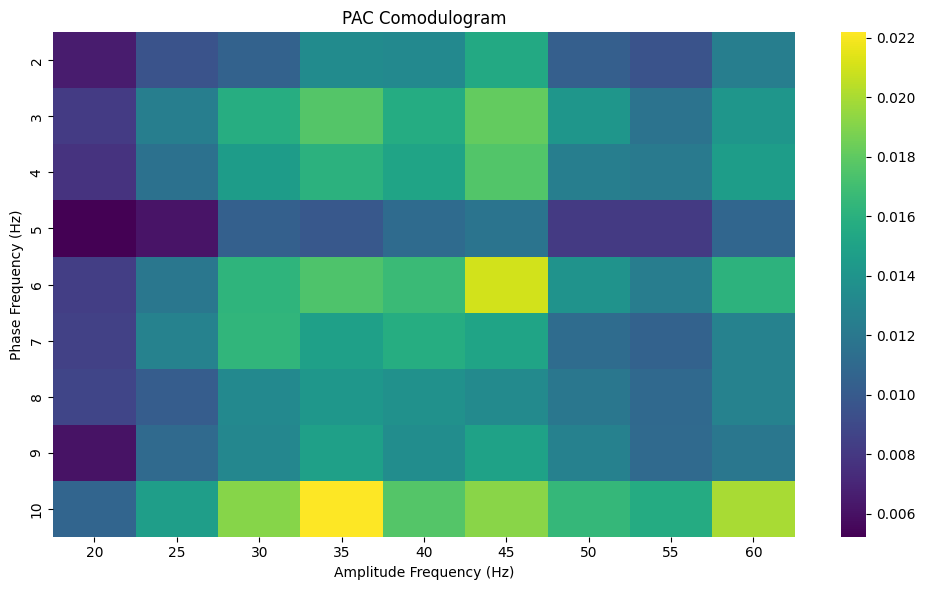

In [178]:
def plot_comodulogram(mi_matrix, f_pha_list, f_amp_list, chi=None,sigma=None,a=None, b=None):
    """
    رسم کومدولوگرام (heatmap) برای PAC

    Parameters:
    - mi_matrix: ndarray (n_amp_freqs, n_phase_freqs)
    - f_pha_list: list of phase frequencies (x-axis)
    - f_amp_list: list of amplitude frequencies (y-axis)
    - chi: مقدار chi فقط برای نمایش عنوان
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(mi_matrix, aspect='auto', origin='lower',
               extent=[f_pha_list[0], f_pha_list[-1], f_amp_list[0], f_amp_list[-1]],
               cmap='hot')
    plt.colorbar(label='Modulation Index (MI)')
    plt.xlabel('Phase Frequency (Hz)')
    plt.ylabel('Amplitude Frequency (Hz)')
    title = f'PAC Comodulogram' + (f' (chi = {chi})' if chi is not None else '')+(f' (sigma={sigma_n})'if a is not None else "")+ (f' (a={a})'if a is not None else "") +(f" (b={b})" if b is not None else"")
    plt.title(title)
    plt.tight_layout()
    plt.show()
phase_freqs = np.arange(2, 11, 1)        # فرکانس‌های فاز: 4 تا 12 هرتز
amp_freqs = np.arange(20, 65, 5)        # فرکانس‌های دامنه: 30 تا 100 هرتز

def compute_pac(phi_tf, A_tf, phase_freqs, amp_freqs):
    pac_matrix = np.zeros((len(phase_freqs), len(amp_freqs)))
    for i, pf in enumerate(phase_freqs):
      for j, af in enumerate(amp_freqs):
          mean_amp= proxy_histogram(phi_tf[pf],A_tf[af])[2]
          D_KL, MI = compute_kl_mi(mean_amp)
          pac_matrix[i, j] = MI
    return pac_matrix

matrix = compute_pac(phi_tf, A_tf, phase_freqs, amp_freqs)

plt.figure(figsize=(10, 6))
sns.heatmap(matrix, xticklabels=amp_freqs, yticklabels=phase_freqs,
            cmap='viridis', mask=np.isnan(matrix))
plt.xlabel('Amplitude Frequency (Hz)')
plt.ylabel('Phase Frequency (Hz)')
plt.title('PAC Comodulogram')
plt.tight_layout()
plt.show()



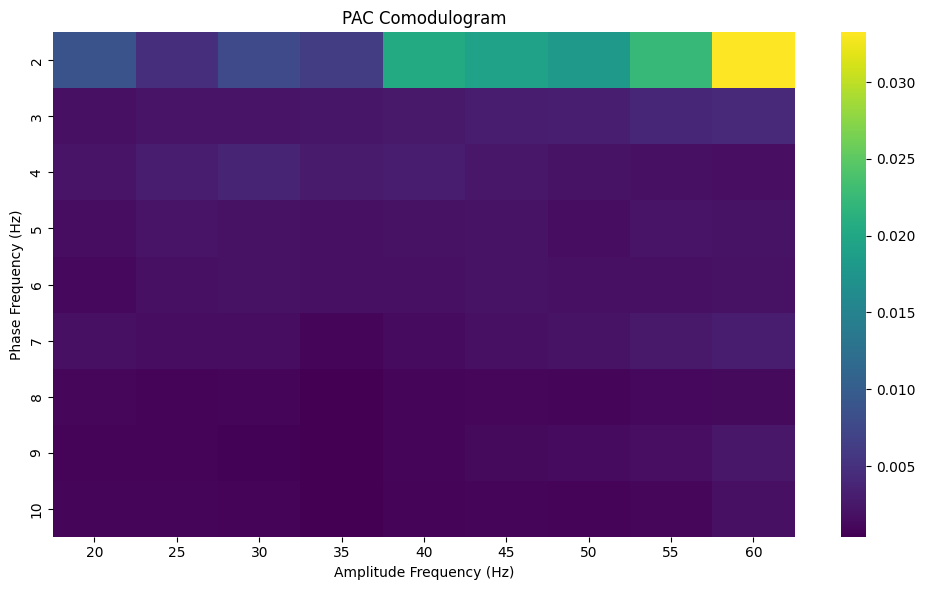

In [185]:
phase_freqs = np.arange(2, 11, 1)        # فرکانس‌های فاز: 4 تا 12 هرتز
amp_freqs = np.arange(20, 65, 5)        # فرکانس‌های دامنه: 30 تا 100 هرتز

def compute_pac(phi_tf, A_tf, phase_freqs, amp_freqs, n_bins=18):
    pac_matrix = np.zeros((len(phase_freqs), len(amp_freqs)))
    for i, pf in enumerate(phase_freqs):
        for j, af in enumerate(amp_freqs):
            phi = phi_tf[i]       # ✅ index, not frequency!
            amp = A_tf[j]
            mean_amp = proxy_histogram(phi, amp, n_bins=n_bins)[2]
            _, MI = compute_kl_mi(mean_amp)
            pac_matrix[i, j] = MI
    return pac_matrix

matrix = compute_pac(phi_tf, A_tf, phase_freqs, amp_freqs)

plt.figure(figsize=(10, 6))
sns.heatmap(matrix, xticklabels=amp_freqs, yticklabels=phase_freqs,
            cmap='viridis', mask=np.isnan(matrix))
plt.xlabel('Amplitude Frequency (Hz)')
plt.ylabel('Phase Frequency (Hz)')
plt.title('PAC Comodulogram')
plt.tight_layout()
plt.show()



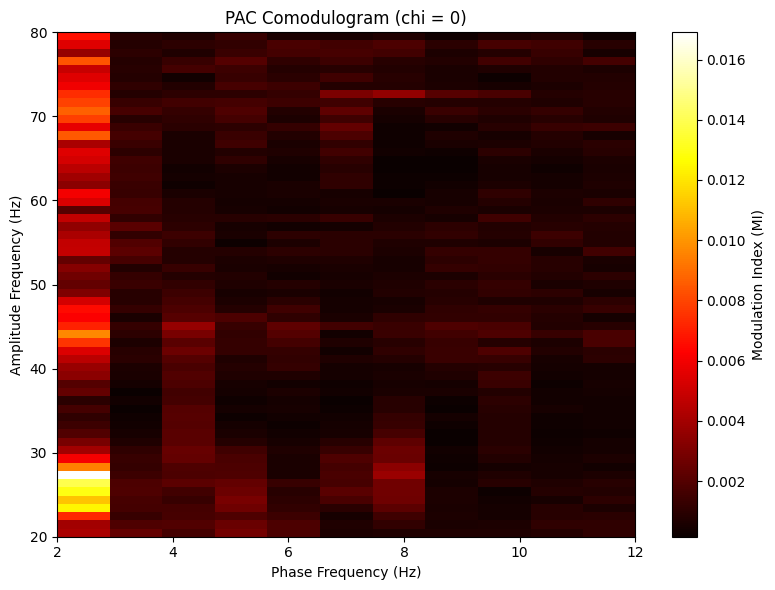

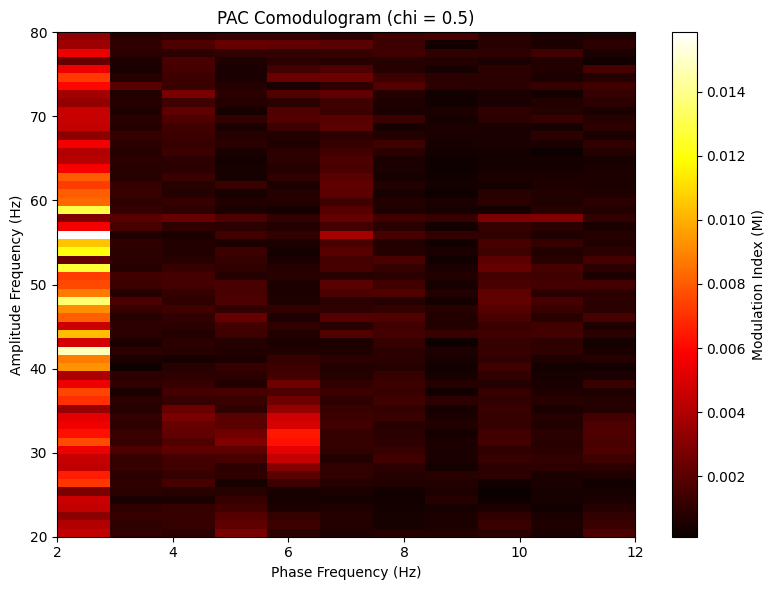

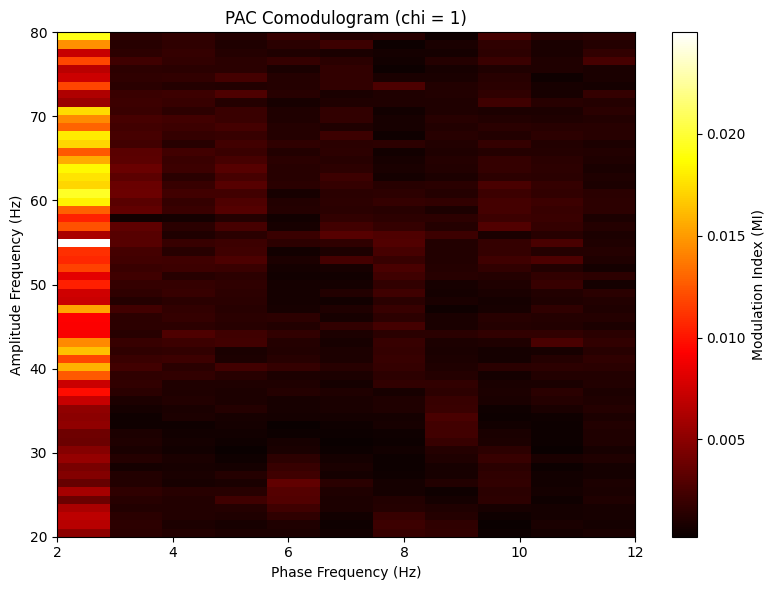

In [186]:
chi_values = [0, 0.5, 1]
for chi in chi_values:
    # generate signal
    x_p, x_a, _, _, _ = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi)

    # wavelet decomposition
    phi_tf, A_tf, f_p, f_a = time_frequency_analysis_pywt(x_p, x_a, fs=500)

    # PAC computation
    matrix = compute_pac(phi_tf, A_tf, f_p, f_a)

    # plot
    plot_comodulogram(matrix.T, f_p, f_a, chi=chi)


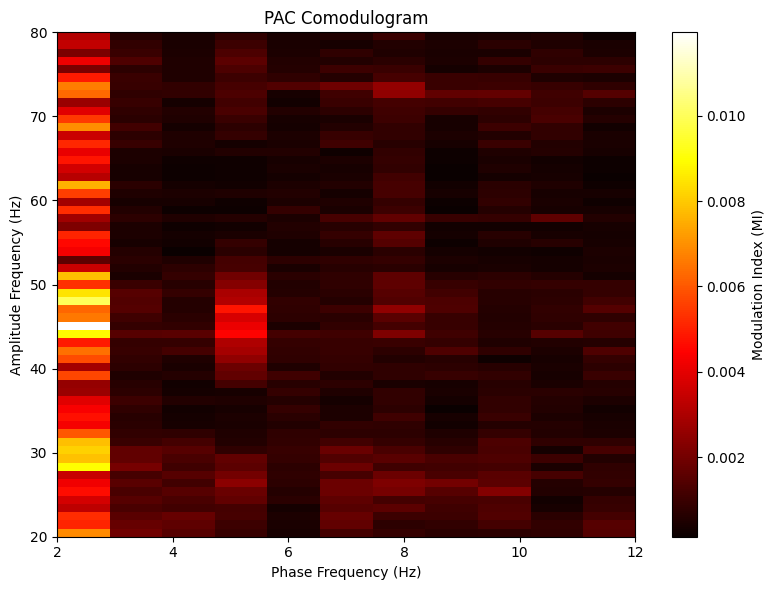

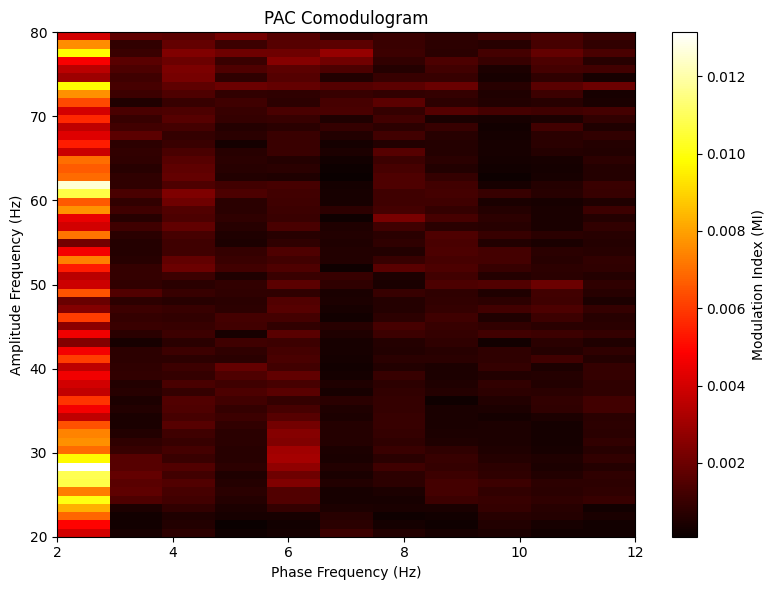

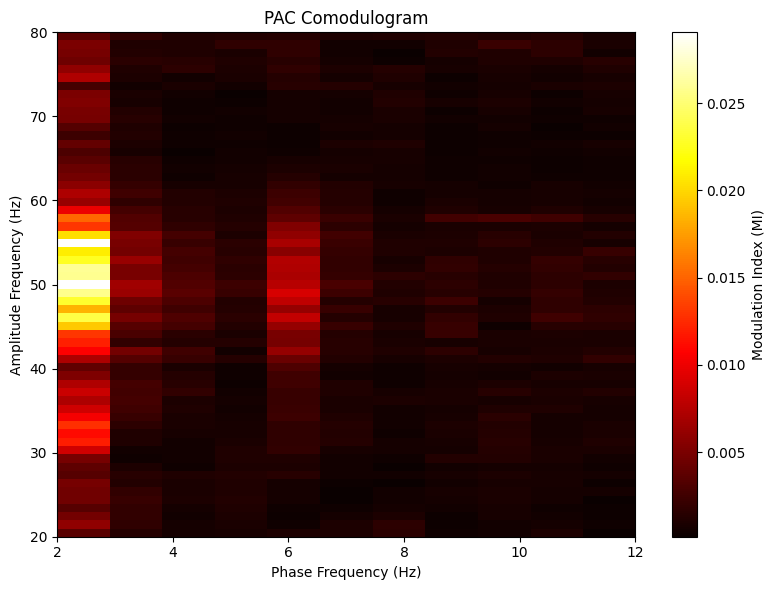

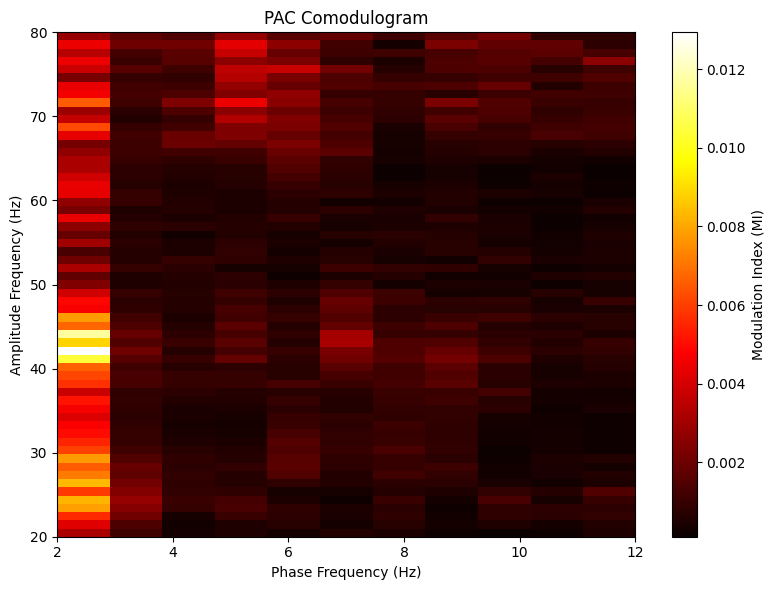

In [187]:
chi=0
sigma_values = [ 0.5, 1, 2 ,3]
for sigma_n in sigma_values:
    # generate signal
    x_p, x_a, _, _, _ = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi)

    # wavelet decomposition
    phi_tf, A_tf, f_p, f_a = time_frequency_analysis_pywt(x_p, x_a, fs=500)

    # PAC computation
    matrix = compute_pac(phi_tf, A_tf, f_p, f_a)

    # plot
    plot_comodulogram(matrix.T, f_p, f_a, chi=None,sigma=sigma_n)



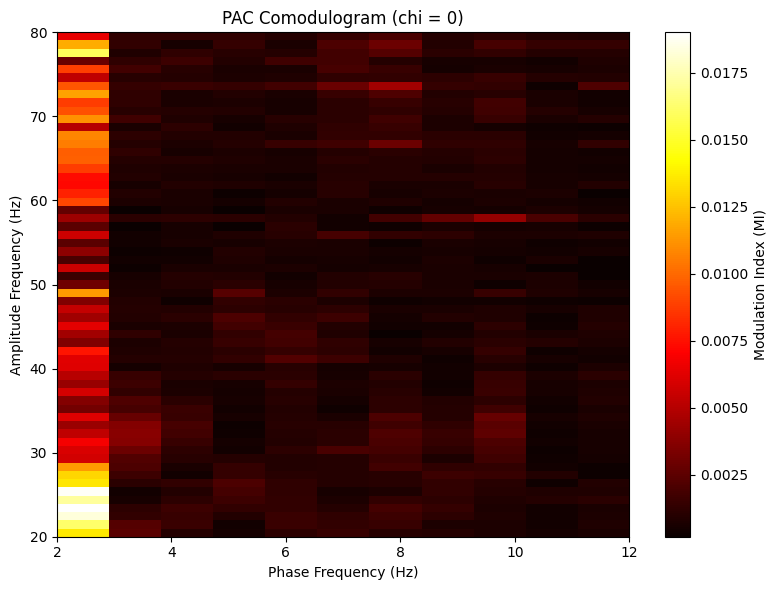

In [188]:
chi=0
sigma_n=0.5
x_p, x_a, _, _, _ = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi)
fs = 500                     # Sampling frequency (Hz)
shift_time = 0.1             # Shift in seconds (100 ms)
samples_to_shift = int(fs * shift_time)  # Number of samples to shift

# Apply circular shift
x_p_shifted = np.roll(x_p, samples_to_shift)

# wavelet decomposition
phi_tf, A_tf, f_p, f_a = time_frequency_analysis_pywt(x_p_shifted, x_a, fs=500)

# PAC computation
matrix = compute_pac(phi_tf, A_tf, f_p, f_a)

# plot
plot_comodulogram(matrix.T, f_p, f_a, chi=chi,sigma=sigma_n)



#اثر منبع مشترک

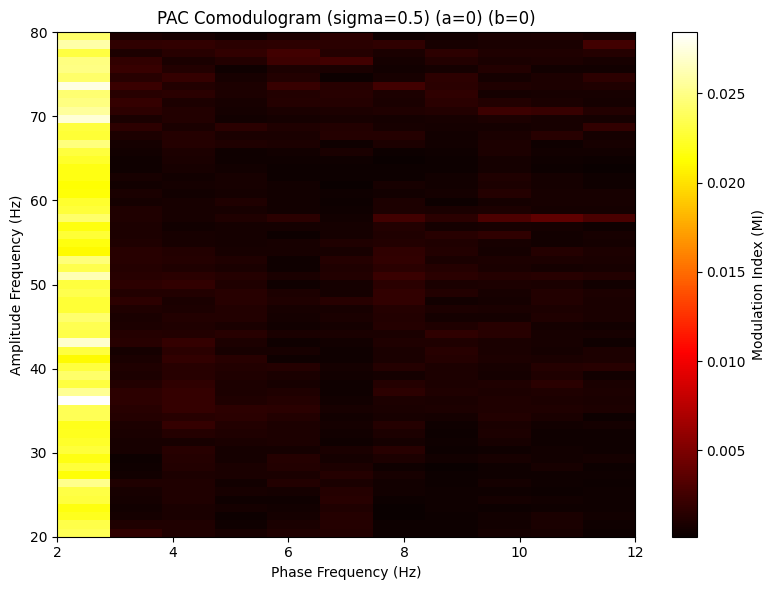

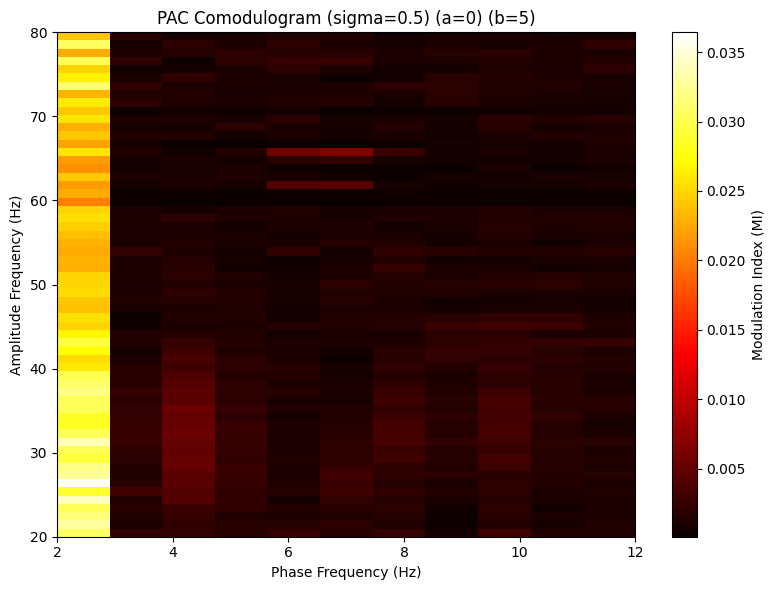

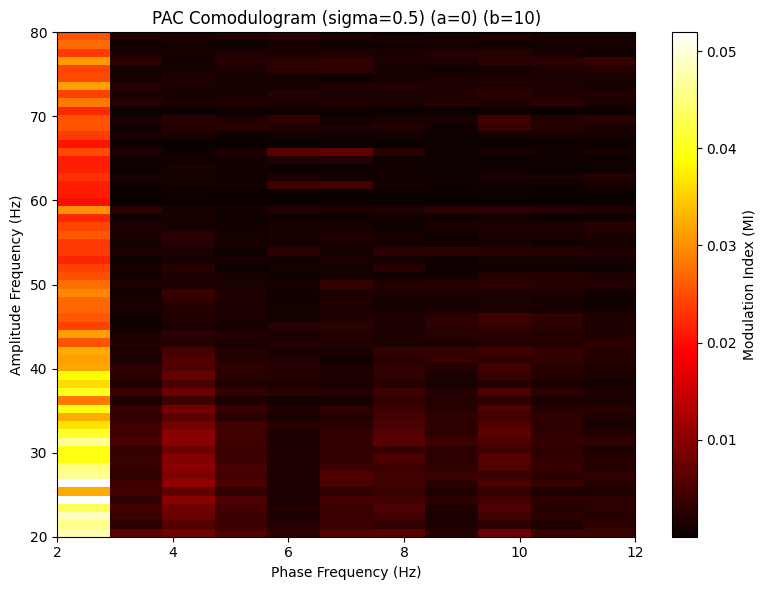

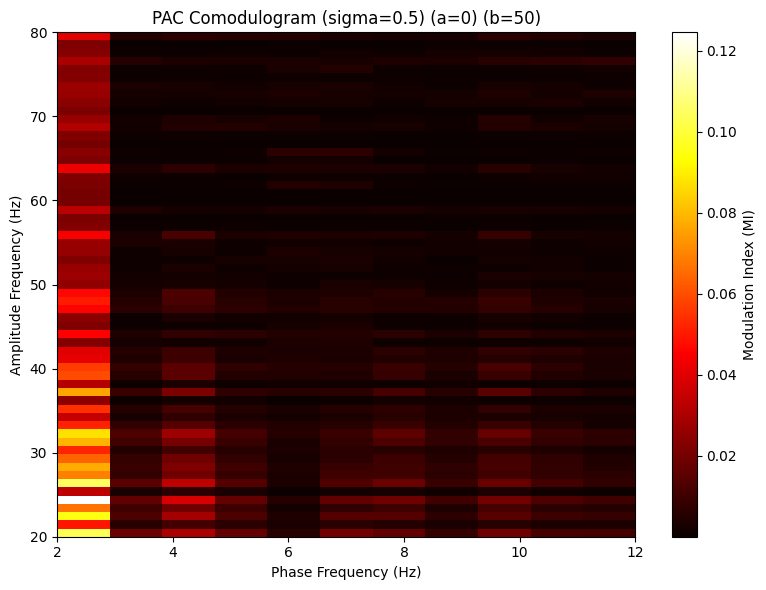

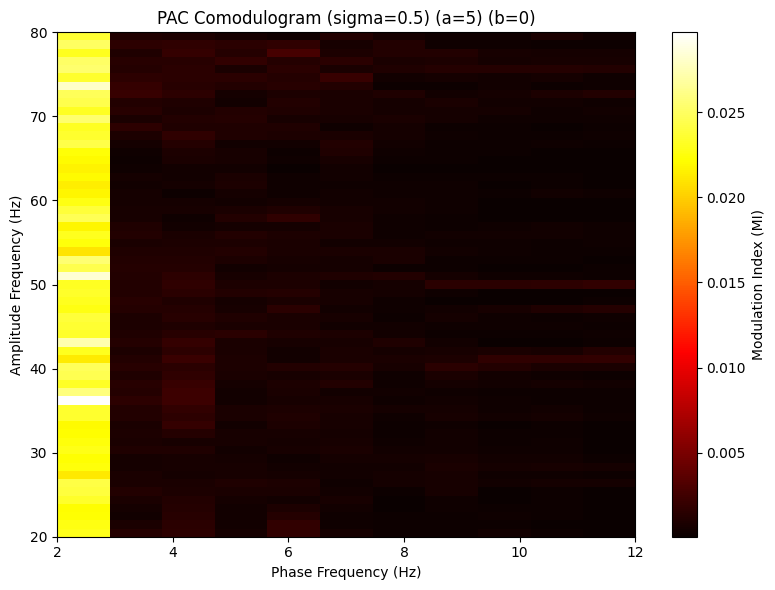

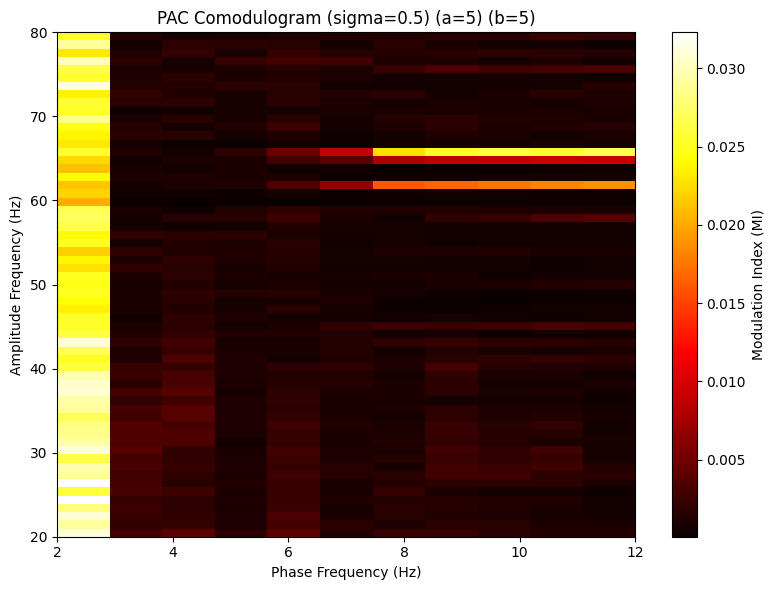

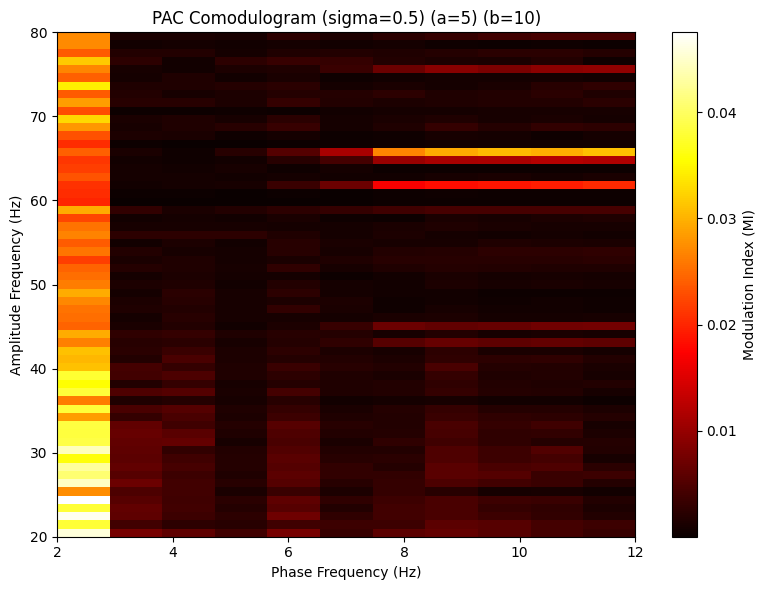

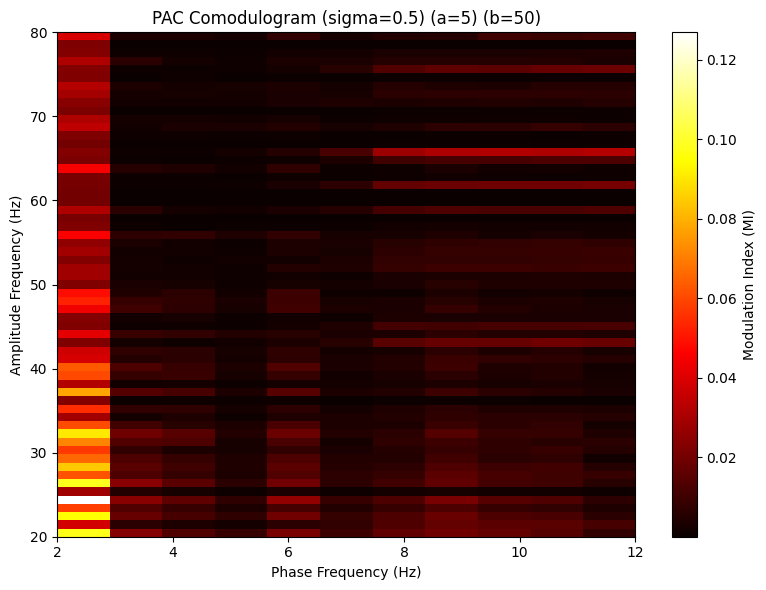

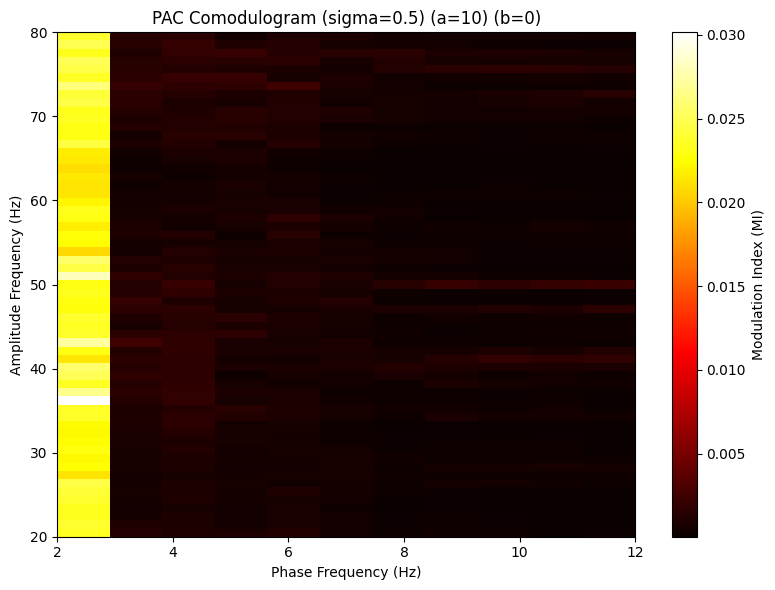

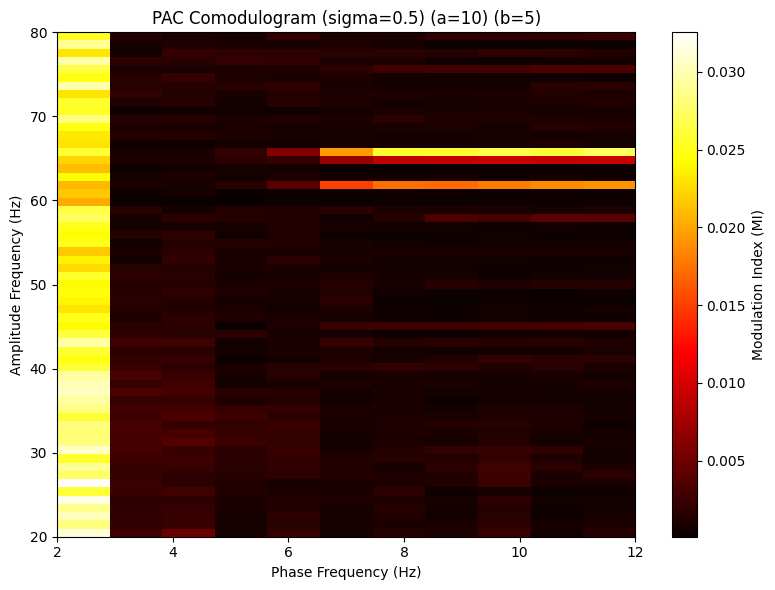

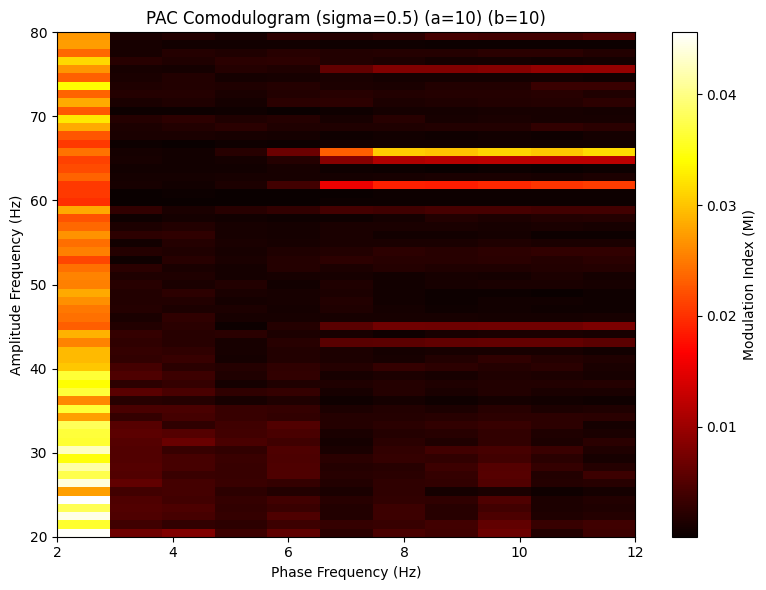

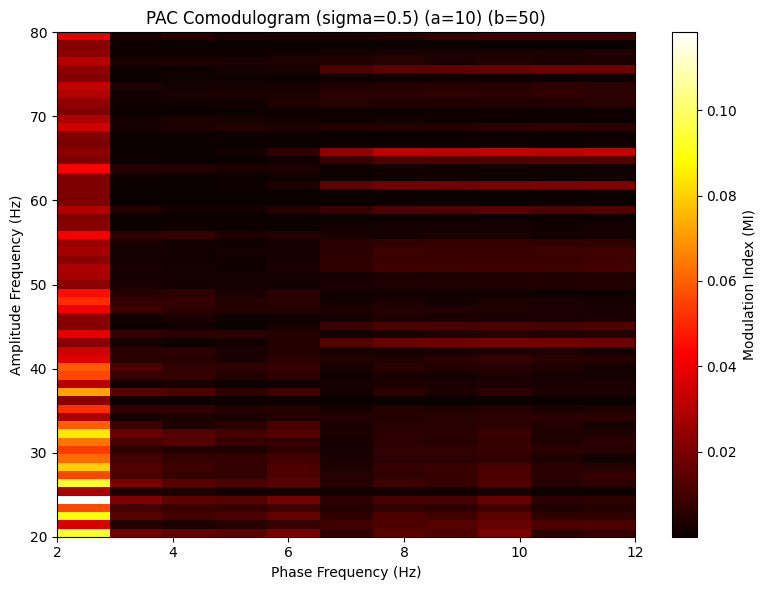

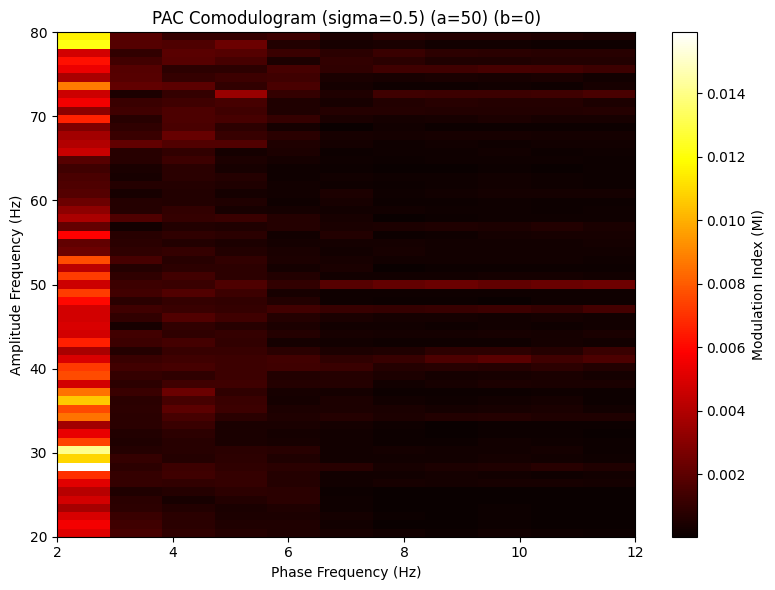

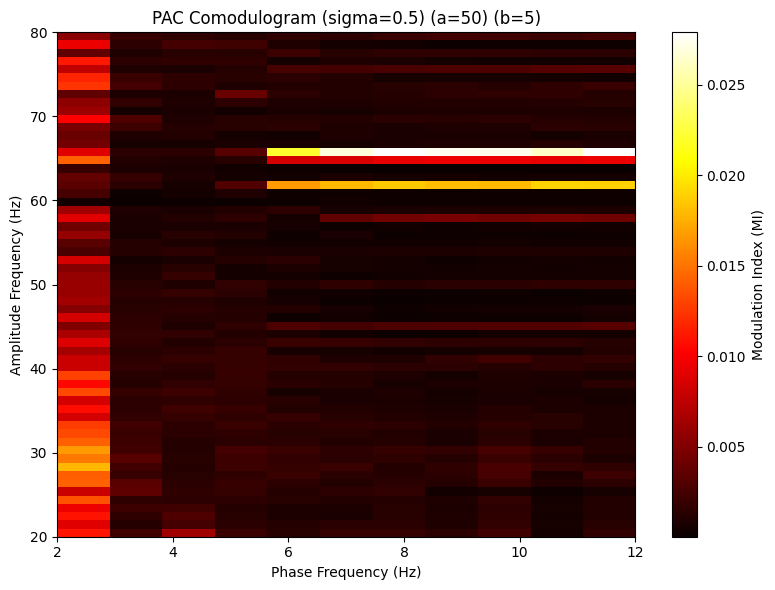

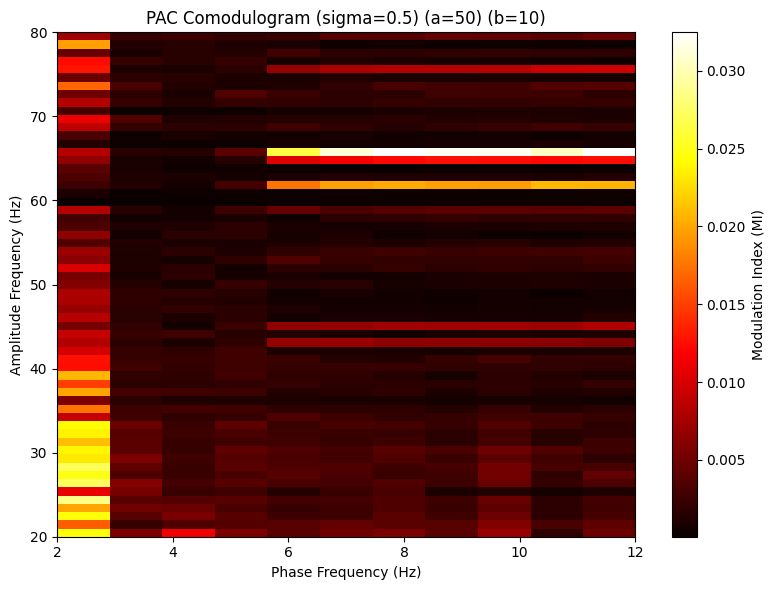

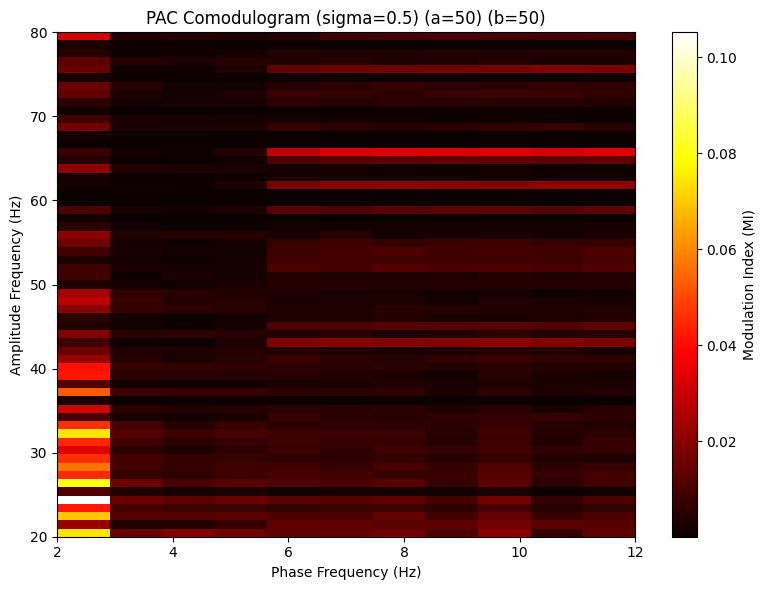

In [189]:
f_phase=5
f_amp=60
kp = 1
ka = 1
sigma_n = 0.5
chi = 0
fcs=40
x_p, x_a, _, _, _ = signal_generator(f_phase, f_amp, kp, ka, sigma_n, chi)


fs = 500  # Sampling rate
t = np.linspace(0, 1, fs, endpoint=False)  # Time from 0 to 1 sec

A=[0,5,10,50]
B=[0,5,10,50]
for a in A:
  for b in B:
    xp = x_p + a *np.cos(2*np.pi*fcs*t)
    xa = x_a + b *np.cos(2*np.pi*fcs*t)
    # wavelet decomposition
    phi_tf, A_tf, f_p, f_a = time_frequency_analysis_pywt(xp, xa, fs=500)

    # PAC computation
    matrix = compute_pac(phi_tf, A_tf, f_p, f_a)

    # plot
    plot_comodulogram(matrix.T, f_p, f_a, chi=None,sigma=None,a=a, b=b)
